<a href="https://colab.research.google.com/github/brunopn-code/bank-marketing-propensity/blob/main/notebooks/03_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling and Evaluation

This notebook builds classification models to predict whether a client subscribed to a term deposit.

Because the dataset is imbalanced, models will be evaluated using precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy alone.

Two modeling approaches are compared:

1. A model including `duration`, used as a performance upper bound.
2. A realistic model excluding `duration`, used for pre-campaign client targeting.

In [598]:
import pandas as pd
import numpy as np

from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import permutation_importance
!pip install imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import git

In [489]:
!git clone https://github.com/brunopn-code/bank-marketing-propensity.git

fatal: destination path 'bank-marketing-propensity' already exists and is not an empty directory.


In [490]:
df = pd.read_csv("bank-marketing-propensity/data/processed/bank_marketing_clean.csv")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [491]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [492]:
X = df.drop(columns=["y", "target"])
y = df["target"]

In [493]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [494]:
y_train.value_counts(normalize=True) * 100

,proportion
target,
0,88.734446
1,11.265554


In [495]:
y_test.value_counts(normalize=True) * 100

,proportion
target,
0,88.73513
1,11.26487


In [496]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [497]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp_var_rate',
 'cons_price_idx',
 'cons_conf_idx',
 'euribor3m',
 'nr_employed']

In [498]:
numeric_features_no_duration = [
    col for col in numeric_features if col != "duration"
]
numeric_features_no_duration

['age',
 'campaign',
 'pdays',
 'previous',
 'emp_var_rate',
 'cons_price_idx',
 'cons_conf_idx',
 'euribor3m',
 'nr_employed']

In [499]:
preprocessor_with_duration = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [500]:
preprocessor_no_duration = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_no_duration),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

##Dummy Baseline Model
We do this so we can have a baseline to compare our future models

In [501]:
dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train,y_train)

y_pred_dummy = dummy_model.predict(X_test)

In [502]:
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Precision:", precision_score(y_test, y_pred_dummy, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dummy))
print("F1-score:", f1_score(y_test, y_pred_dummy))

Accuracy: 0.8873512988589464
Precision: 0.0
Recall: 0.0
F1-score: 0.0


This baseline achieved high accuracy because the dataset is imbalanced, but it failed completely on the positive class, with precision, recall, and F1-score equal to zero. Confirming that accuracy alone is not appropriate for evaluating this project.

## Logistic Regression Models

Logistic Regression is used as the first real classification model because it is simple, interpretable, and useful as a baseline for comparison with more complex models.

Because the dataset is imbalanced, `class_weight="balanced"` is used to give more importance to the minority class.

In [503]:
def evaluate_model(model_name, y_test, y_pred, y_prob):
  results = {
      "model" : model_name,
      "accuracy" : accuracy_score(y_test, y_pred),
      "precision" : precision_score(y_test, y_pred, zero_division=0),
      "recall" : recall_score(y_test, y_pred),
      "f1-score" : f1_score(y_test, y_pred),
      "roc-auc" : roc_auc_score(y_test, y_prob)
  }

  return results

In [504]:
log_reg_with_duration = Pipeline(
    steps = [
        ("preprocessor", preprocessor_with_duration),
        ("model", LogisticRegression(
            max_iter = 1000,
            class_weight = "balanced",
            random_state = 42
        ))
    ]
)

log_reg_with_duration.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [505]:
y_pred_lr_duration = log_reg_with_duration.predict(X_test)
y_prob_lr_duration = log_reg_with_duration.predict_proba(X_test)[:,1]

results_lr_duration = evaluate_model(
    "Logistic Regression with Duration",
    y_test,
    y_pred_lr_duration,
    y_prob_lr_duration
)

results_lr_duration

{'model': 'Logistic Regression with Duration',
 'accuracy': 0.8651371692158291,
 'precision': 0.4512,
 'recall': 0.9116379310344828,
 'f1-score': 0.6036389582590082,
 'roc-auc': np.float64(0.9438378579178264)}

In [506]:
confusion_matrix(y_test, y_pred_lr_duration)

array([[6281, 1029],
       [  82,  846]])

In [507]:
print(classification_report(y_test, y_pred_lr_duration))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238



In [508]:
log_reg_no_duration = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

log_reg_no_duration.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [509]:
y_pred_lr_no_duration = log_reg_no_duration.predict(X_test)
y_proba_lr_no_duration = log_reg_no_duration.predict_proba(X_test)[:, 1]

results_lr_no_duration = evaluate_model(
    "Logistic Regression without duration",
    y_test,
    y_pred_lr_no_duration,
    y_proba_lr_no_duration
)

results_lr_no_duration

{'model': 'Logistic Regression without duration',
 'accuracy': 0.8350327749453751,
 'precision': 0.3678724708767627,
 'recall': 0.646551724137931,
 'f1-score': 0.46893317702227433,
 'roc-auc': np.float64(0.8009417454832776)}

In [510]:
confusion_matrix(y_test, y_pred_lr_no_duration)

array([[6279, 1031],
       [ 328,  600]])

In [511]:
print(classification_report(y_test, y_pred_lr_no_duration))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238



In [512]:
logistic_results = pd.DataFrame([
    results_lr_duration,
    results_lr_no_duration
])

logistic_results

,model,accuracy,precision,recall,f1-score,roc-auc
0,Logistic Regression with Duration,0.865137,0.451200,0.911638,0.603639,0.943838
1,Logistic Regression without duration,0.835033,0.367872,0.646552,0.468933,0.800942


### Logistic Regression Results

The Logistic Regression model including `duration` performs much better than the model excluding `duration`. It achieves higher recall, F1-score, and ROC-AUC.

However, this result should be interpreted carefully because `duration` is only known after the client has already been contacted. Therefore, the model including `duration` acts as a performance upper bound, but it is not realistic for pre-campaign client targeting.

The Logistic Regression model excluding `duration` is weaker, but it is more realistic for the business problem. It still performs much better than the dummy baseline because it identifies a meaningful number of subscribers instead of always predicting the majority class.


-------

## Statistical Association Analysis

Before training more complex models, we perform statistical association analysis to support the patterns observed during EDA.

This section checks how strongly each variable is associated with the target variable, `target`, where:

* `1` means the client subscribed to a term deposit
* `0` means the client did not subscribe

For categorical variables, we use the chi-square test and Cramér's V.

For numeric variables, we use point-biserial correlation and the Mann-Whitney U test.

Because this dataset is relatively large, p-values may become statistically significant even for small effects. For this reason, the interpretation should focus more on effect size measures such as Cramér's V and correlation strength, not only on p-values.


In [513]:
train_df = X_train.copy()
train_df["target"] = y_train

train_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,target
25611,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,...,4,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,0
26010,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,...,2,999,1,failure,-0.1,93.200,-42.0,4.120,5195.8,0
40194,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,...,1,999,0,nonexistent,-1.7,94.215,-40.3,0.870,4991.6,1
297,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
36344,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,...,2,999,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2,0


### Categorical Association Analysis

For categorical variables, we use the chi-square test to check whether the distribution of subscription outcomes differs across categories.

We also calculate Cramér's V, which measures the strength of association between each categorical feature and the target variable.

Cramér's V ranges from 0 to 1:

* values near 0 indicate weak association
* higher values indicate stronger association


In [514]:
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

In [515]:
categorical_association_results = []

for col in categorical_features:
    contingency_table = pd.crosstab(train_df[col], train_df["target"])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    cv = cramers_v(contingency_table)

    categorical_association_results.append({
        "feature": col,
        "chi2_statistic": chi2,
        "p_value": p_value,
        "cramers_v": cv
    })

categorical_association_df = (
    pd.DataFrame(categorical_association_results)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

categorical_association_df

,feature,chi2_statistic,p_value,cramers_v
0,poutcome,3384.732687,0.000000e+00,0.320505
1,month,2458.782516,0.000000e+00,0.273170
2,job,756.330358,4.475532e-155,0.151505
3,contact,675.098190,7.778686e-149,0.143138
4,default,323.885542,4.668187e-71,0.099144
5,education,165.703165,2.019915e-32,0.070915
6,marital,110.260620,9.643782e-24,0.057847
7,day_of_week,12.890707,1.182235e-02,0.019779
8,housing,3.181591,2.037634e-01,0.009826
9,loan,0.009170,9.954257e-01,0.000528


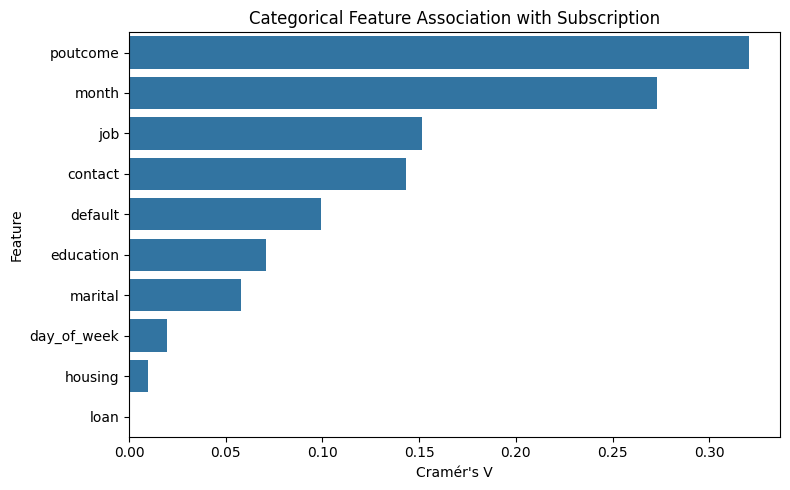

In [516]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=categorical_association_df,
    x="cramers_v",
    y="feature"
)
plt.title("Categorical Feature Association with Subscription")
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("stat_categorical_association_cramers_v.png", dpi=300, bbox_inches="tight")
plt.show()

### Numeric Association Analysis

For numeric variables, we use point-biserial correlation because the target variable is binary.

This measures whether higher or lower values of each numeric feature are associated with subscription.

Positive values indicate that higher feature values are associated with subscription. Negative values indicate that lower feature values are associated with subscription.


In [517]:
numeric_association_results = []

for col in numeric_features:
    corr, p_value = pointbiserialr(train_df[col], train_df["target"])

    numeric_association_results.append({
        "feature": col,
        "point_biserial_correlation": corr,
        "p_value": p_value
    })

numeric_association_df = (
    pd.DataFrame(numeric_association_results)
    .sort_values(
        "point_biserial_correlation",
        key=lambda x: abs(x),
        ascending=False
    )
    .reset_index(drop=True)
)

numeric_association_df

,feature,point_biserial_correlation,p_value
0,duration,0.400752,0.000000e+00
1,nr_employed,-0.349729,0.000000e+00
2,pdays,-0.325539,0.000000e+00
3,euribor3m,-0.303174,0.000000e+00
4,emp_var_rate,-0.293690,0.000000e+00
5,previous,0.229759,0.000000e+00
6,cons_price_idx,-0.132520,5.723661e-129
7,campaign,-0.065462,1.256583e-32
8,cons_conf_idx,0.055327,9.155033e-24
9,age,0.028673,1.933636e-07


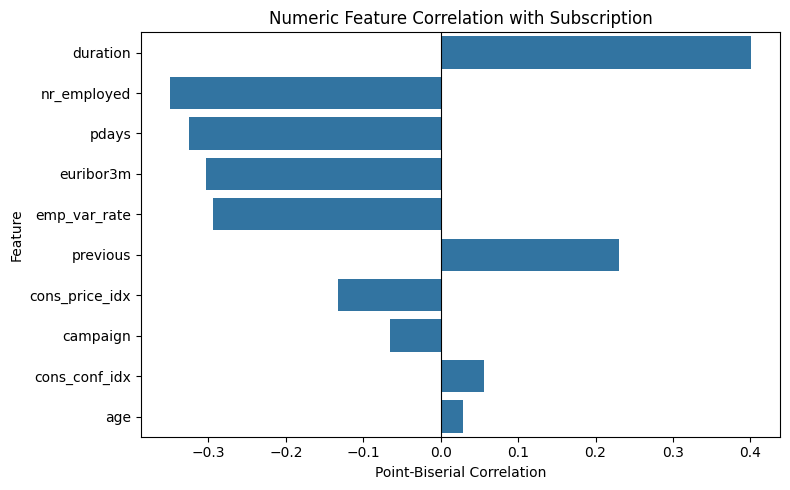

In [518]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=numeric_association_df,
    x="point_biserial_correlation",
    y="feature"
)
plt.title("Numeric Feature Correlation with Subscription")
plt.xlabel("Point-Biserial Correlation")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("stat_numeric_association_point_biserial.png", dpi=300, bbox_inches="tight")
plt.show()

In [519]:
mannwhitney_results = []

for col in numeric_features:
    group_no = train_df.loc[train_df["target"] == 0, col]
    group_yes = train_df.loc[train_df["target"] == 1, col]

    statistic, p_value = mannwhitneyu(
        group_no,
        group_yes,
        alternative="two-sided"
    )

    mannwhitney_results.append({
        "feature": col,
        "mannwhitney_statistic": statistic,
        "p_value": p_value,
        "median_no": group_no.median(),
        "median_yes": group_yes.median()
    })

mannwhitney_df = (
    pd.DataFrame(mannwhitney_results)
    .sort_values("p_value")
    .reset_index(drop=True)
)

mannwhitney_df

,feature,mannwhitney_statistic,p_value,median_no,median_yes
0,duration,19822288.5,0.000000e+00,164.000,448.000
1,pdays,64839345.5,0.000000e+00,999.000,999.000
2,emp_var_rate,77362732.5,0.000000e+00,1.100,-1.800
3,euribor3m,80294528.0,0.000000e+00,4.857,1.266
4,nr_employed,80829252.5,0.000000e+00,5195.800,5099.100
5,previous,42275074.0,1.172024e-295,0.000,0.000
6,cons_price_idx,65917288.5,7.185829e-103,93.918,93.200
7,campaign,59981617.5,2.862154e-28,2.000,2.000
8,cons_conf_idx,50118218.5,1.775277e-14,-41.800,-40.400
9,age,55552629.0,1.834699e-02,38.000,37.000


### Statistical Association Findings

The statistical association analysis supports the patterns observed during EDA.

Among categorical variables, `poutcome` shows the strongest association with subscription, followed by `month`, `job`, and `contact`. This confirms that previous campaign outcome, campaign timing, client occupation, and contact channel are important variables for understanding subscription behavior.

Among numeric variables, `duration` shows the strongest positive association with subscription. However, this variable is a data leakage risk because it is only known after the call has occurred. Therefore, it should not be used in the final realistic pre-campaign targeting model.

The economic variables `nr_employed`, `euribor3m`, and `emp_var_rate` show strong negative associations with subscription. This suggests that clients were more likely to subscribe during certain economic conditions.

The variable `pdays` also shows a strong association, but it must be interpreted carefully because the value `999` means the client was not previously contacted. For this reason, feature engineering should create a clearer variable indicating whether the client had previous campaign contact.

The Mann-Whitney U test confirms that several numeric variables have statistically different distributions between subscribers and non-subscribers. However, because the dataset is large, p-values are often very small. Therefore, interpretation should focus more on effect size, business meaning, and model performance than on p-values alone.

Overall, the strongest variables identified before model comparison are:

* `duration`
* `poutcome`
* `month`
* `job`
* `contact`
* `nr_employed`
* `pdays`
* `euribor3m`
* `emp_var_rate`
* `previous`


-------

### Feature Engineering

Based on the EDA and statistical association analysis, we create additional features to make some variables easier for the model to use and easier to interpret from a business perspective.

The main engineered features are:

- `previously_contacted`: identifies whether the client was contacted in a previous campaign
- `pdays_clean`: replaces the artificial value `999` with `0`
- `age_group`: groups clients into age bands
- `campaign_group`: groups clients by number of campaign contacts

The original `pdays` variable uses `999` to represent clients who were not previously contacted. Because this is not a real number of days, we replace it with clearer features.

In [520]:
df_model= df.copy()

df_model["previously_contacted"] = np.where(
    df_model["pdays"] == 999,
    0,
    1
)

df_model["pdays_clean"] = np.where(
    df_model["pdays"] == 999,
    0,
    df_model["pdays"]
)

df_model["age_group"] = pd.cut(
    df_model["age"],
    bins = [0,30,40,50,60,70,100],
    labels = ["Under 30", "30-39", "40-49", "50-59", "60-69", "70+"],
    right=False
)

df_model["campaign_group"] = pd.cut(
    df_model["campaign"],
    bins = [0,1,2,3,5,14, np.inf],
    labels = ["1 contact", "2 contacts", "3 contacts", "4-5 contacts", "6-14 contacts", "14+ contacts"],
    right = True
)

df_model.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,target,previously_contacted,pdays_clean,age_group,campaign_group
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,0,0,0,50-59,1 contact
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,0,0,0,50-59,1 contact
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,0,0,0,30-39,1 contact
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,0,0,0,40-49,1 contact
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,0,0,0,50-59,1 contact


In [521]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   age                   41188 non-null  int64   
 1   job                   41188 non-null  object  
 2   marital               41188 non-null  object  
 3   education             41188 non-null  object  
 4   default               41188 non-null  object  
 5   housing               41188 non-null  object  
 6   loan                  41188 non-null  object  
 7   contact               41188 non-null  object  
 8   month                 41188 non-null  object  
 9   day_of_week           41188 non-null  object  
 10  duration              41188 non-null  int64   
 11  campaign              41188 non-null  int64   
 12  pdays                 41188 non-null  int64   
 13  previous              41188 non-null  int64   
 14  poutcome              41188 non-null  object  
 15  em

------

### Preparing the Feature-Engineered Dataset

After creating the engineered variables, we prepare a new modeling dataset.

The original `pdays` variable is removed because the value `999` does not represent a real number of days. It has been replaced by:

- `previously_contacted`
- `pdays_clean`

As before, we will keep two modeling versions:

1. with `duration`, used as an upper-bound model
2. without `duration`, used as the realistic pre-campaign targeting model

In [522]:
X_fe = df_model.drop(columns=["y", "target", "pdays"])
y_fe = df_model["target"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size = 0.2,
    random_state = 42,
    stratify = y_fe
)

categorical_features_fe = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features_fe = X_train_fe.select_dtypes(include = ["float", "int64"]).columns.tolist()

numeric_features_fe_no_duration = [
    col for col in numeric_features_fe
    if col != "duration"
]

len(categorical_features_fe), len(numeric_features_fe), len(numeric_features_fe_no_duration)

(12, 11, 10)

In [523]:
preprocessor_fe_with_duration = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_fe),
        ("cat",OneHotEncoder(handle_unknown="ignore"), categorical_features_fe)
    ]
)

preprocessor_fe_with_no_duration = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_fe_no_duration),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_fe)
    ]
)

------

### Logistic Regression After Feature Engineering

We now train Logistic Regression again using the feature-engineered dataset.

The purpose is to check whether the engineered variables improve the realistic model that excludes `duration`.

This model should be compared mainly against the previous Logistic Regression model without `duration`, because both represent pre-campaign targeting scenarios.

In [524]:
log_reg_fe_no_duration = Pipeline(
    steps = [
        ("preprocessor", preprocessor_fe_with_no_duration),
        ("model", LogisticRegression(
            max_iter = 1000,
            class_weight="balanced",
            random_state = 42
        ))
    ]
)

log_reg_fe_no_duration.fit(X_train_fe,y_train_fe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed',
                                                   'previously_contacted',
                                                   'pdays_clean']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome', 'age_group',
                                                   'campaign_group'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [525]:
y_pred_lr_fe_no_duration = log_reg_fe_no_duration.predict(X_test_fe)
y_prob_lr_fe_no_duration = log_reg_fe_no_duration.predict_proba(X_test_fe)[:,1]

results_lr_fe_no_duration = evaluate_model(
    "Logistic Regression FE without duration",
    y_test_fe,
    y_pred_lr_fe_no_duration,
    y_prob_lr_fe_no_duration
)

results_lr_fe_no_duration

{'model': 'Logistic Regression FE without duration',
 'accuracy': 0.8324836125273124,
 'precision': 0.36369119420989143,
 'recall': 0.6497844827586207,
 'f1-score': 0.46635730858468677,
 'roc-auc': np.float64(0.800812906858814)}

In [526]:
confusion_matrix(y_test_fe, y_pred_lr_fe_no_duration)

array([[6255, 1055],
       [ 325,  603]])

In [527]:
print(classification_report(y_test_fe, y_pred_lr_fe_no_duration))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.36      0.65      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238



In [528]:
logistic_results_updated = pd.DataFrame([
    results_lr_duration,
    results_lr_no_duration,
    results_lr_fe_no_duration
])

logistic_results_updated

,model,accuracy,precision,recall,f1-score,roc-auc
0,Logistic Regression with Duration,0.865137,0.451200,0.911638,0.603639,0.943838
1,Logistic Regression without duration,0.835033,0.367872,0.646552,0.468933,0.800942
2,Logistic Regression FE without duration,0.832484,0.363691,0.649784,0.466357,0.800813


### Feature Engineering Result

The feature-engineered Logistic Regression model did not improve performance compared with the original Logistic Regression model without `duration`.

The F1-score and ROC-AUC remained almost unchanged:

- Original Logistic Regression without `duration`: F1 = 0.469, ROC-AUC = 0.801
- Feature-engineered Logistic Regression without `duration`: F1 = 0.466, ROC-AUC = 0.801

This suggests that the engineered variables did not add meaningful predictive value for Logistic Regression.

For this reason, the original no-duration feature set remains the main realistic modeling baseline.

However, the engineered dataset will still be tested with Random Forest as an ablation experiment, because tree-based models may respond differently to grouped or transformed variables.

-------

## Random Forest Model

Random Forest is an ensemble learning model that combines many decision trees.

Unlike Logistic Regression, Random Forest can capture non-linear relationships and interactions between variables. This makes it useful when the relationship between the input variables and the target is not purely linear.

Since `duration` is a leakage variable, the main Random Forest model is trained without `duration`.

In [529]:
rf_no_duration = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("model", RandomForestClassifier(
            n_estimators= 300,
            max_depth=None,
            min_samples_leaf=5,
            min_samples_split=10,
            class_weight="balanced",
            random_state = 42,
            n_jobs = -1
        ))
    ]
)

rf_no_duration.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5,
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [530]:
rf_pred_no_duration = rf_no_duration.predict(X_test)
rf_prob_no_duration = rf_no_duration.predict_proba(X_test)[:, 1]

results_rf_no_duration = evaluate_model(
    "Random Forest without Duration",
    y_test,
    rf_pred_no_duration,
    rf_prob_no_duration
)

results_rf_no_duration

{'model': 'Random Forest without Duration',
 'accuracy': 0.8730274338431658,
 'precision': 0.4532488114104596,
 'recall': 0.6163793103448276,
 'f1-score': 0.5223744292237443,
 'roc-auc': np.float64(0.8078813416906457)}

In [531]:
confusion_matrix(y_test, rf_pred_no_duration)

array([[6620,  690],
       [ 356,  572]])

In [532]:
print(classification_report(y_test, rf_pred_no_duration))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7310
           1       0.45      0.62      0.52       928

    accuracy                           0.87      8238
   macro avg       0.70      0.76      0.72      8238
weighted avg       0.89      0.87      0.88      8238



### Random Forest After Feature Engineering

Because Random Forest can capture non-linear relationships and feature interactions, the engineered variables may affect it differently than Logistic Regression.

We therefore train a second Random Forest model using the feature-engineered dataset and compare it with the original Random Forest model without `duration`.

In [533]:
rf_fe_no_duration = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe_with_no_duration),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_fe_no_duration.fit(X_train_fe, y_train_fe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed',
                                                   'previously_contacted',
                                                   'pdays_clean']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome', 'age_group',
                                                   'campaign_group'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5,
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [534]:
y_pred_rf_fe_no_duration = rf_fe_no_duration.predict(X_test_fe)
y_prob_rf_fe_no_duration = rf_fe_no_duration.predict_proba(X_test_fe)[:, 1]

results_rf_fe_no_duration = evaluate_model(
    "Random Forest FE without duration",
    y_test_fe,
    y_pred_rf_fe_no_duration,
    y_prob_rf_fe_no_duration
)

results_rf_fe_no_duration

{'model': 'Random Forest FE without duration',
 'accuracy': 0.8743627093954843,
 'precision': 0.4570970328789094,
 'recall': 0.6142241379310345,
 'f1-score': 0.5241379310344828,
 'roc-auc': np.float64(0.8092400437520637)}

In [535]:
confusion_matrix(y_test_fe, y_pred_rf_fe_no_duration)

array([[6633,  677],
       [ 358,  570]])

In [536]:
print(classification_report(y_test_fe, y_pred_rf_fe_no_duration))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7310
           1       0.46      0.61      0.52       928

    accuracy                           0.87      8238
   macro avg       0.70      0.76      0.73      8238
weighted avg       0.89      0.87      0.88      8238



In [537]:
model_results = pd.DataFrame([
    results_lr_duration,
    results_lr_no_duration,
    results_lr_fe_no_duration,
    results_rf_no_duration,
    results_rf_fe_no_duration
])

model_results

,model,accuracy,precision,recall,f1-score,roc-auc
0,Logistic Regression with Duration,0.865137,0.451200,0.911638,0.603639,0.943838
1,Logistic Regression without duration,0.835033,0.367872,0.646552,0.468933,0.800942
2,Logistic Regression FE without duration,0.832484,0.363691,0.649784,0.466357,0.800813
3,Random Forest without Duration,0.873027,0.453249,0.616379,0.522374,0.807881
4,Random Forest FE without duration,0.874363,0.457097,0.614224,0.524138,0.809240


### Random Forest Result

The Random Forest model improved over the Logistic Regression model without `duration`.

Compared with Logistic Regression without `duration`, Random Forest achieved:

- higher accuracy
- higher precision
- higher F1-score
- slightly higher ROC-AUC

However, Random Forest had slightly lower recall than Logistic Regression. This means that it identified fewer actual subscribers, but when it predicted a subscriber, it was more often correct.

Logistic Regression without `duration`:

- Recall: 0.647
- F1-score: 0.469
- ROC-AUC: 0.801

Random Forest without `duration`:

- Recall: 0.616
- F1-score: 0.522
- ROC-AUC: 0.808

This suggests that Random Forest provides a better balance between precision and recall than Logistic Regression for the realistic no-duration modeling scenario.

### Feature Engineering Ablation Result

The engineered features were tested with both Logistic Regression and Random Forest.

For Logistic Regression, the feature-engineered version performed slightly worse than the original no-duration model. For Random Forest, the feature-engineered version performed slightly better, but the improvement was very small.

Random Forest without feature engineering:

- F1-score: 0.522
- ROC-AUC: 0.808

Random Forest with feature engineering:

- F1-score: 0.524
- ROC-AUC: 0.809

The improvement is not large enough to justify the added preprocessing complexity at this stage.

For the next modeling steps, the original no-duration feature set will be used as the main realistic modeling dataset. The feature-engineered dataset will be kept as an experiment and may be revisited later if cross-validation or final model tuning shows that it provides a stable improvement.

## Gradient Boosting Model

Gradient Boosting is an ensemble learning method that builds decision trees sequentially.

Unlike Random Forest, where trees are trained mostly independently, Gradient Boosting trains each new tree to correct the errors made by the previous trees.

This model can capture non-linear relationships and interactions between variables, and often performs well on structured/tabular data.

Since `duration` is a leakage variable, the main Gradient Boosting model is trained without `duration`.

In [542]:
gb_no_duration = Pipeline(
    steps = [
        ("preprocessor", preprocessor_no_duration),
        ("model", GradientBoostingClassifier(
             n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=42
        ))
    ]
)

sample_weights = compute_sample_weight(
    class_weight = "balanced",
    y = y_train
)

gb_no_duration.fit(
    X_train,
    y_train,
    model__sample_weight = sample_weights
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=200, random_state=42,
                                            subsample=0.8))])

In [544]:
y_pred_gb_no_duration = gb_no_duration.predict(X_test)
y_prob_gb_no_duration = gb_no_duration.predict_proba(X_test)[:,1]

results_gb_no_duration = evaluate_model(
    "Gradient Boosting without Duration",
    y_test,
    y_pred_gb_no_duration,
    y_prob_gb_no_duration
)

results_gb_no_duration

{'model': 'Gradient Boosting without Duration',
 'accuracy': 0.8386744355426075,
 'precision': 0.3775198533903482,
 'recall': 0.665948275862069,
 'f1-score': 0.4818713450292398,
 'roc-auc': np.float64(0.813693747346573)}

In [545]:
confusion_matrix(y_test, y_pred_gb_no_duration)

array([[6291, 1019],
       [ 310,  618]])

In [546]:
print(classification_report(y_test, y_pred_gb_no_duration))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.38      0.67      0.48       928

    accuracy                           0.84      8238
   macro avg       0.67      0.76      0.69      8238
weighted avg       0.89      0.84      0.86      8238



In [547]:
model_results = pd.DataFrame([
    results_lr_duration,
    results_lr_no_duration,
    results_lr_fe_no_duration,
    results_rf_no_duration,
    results_rf_fe_no_duration,
    results_gb_no_duration
])

model_results

,model,accuracy,precision,recall,f1-score,roc-auc
0,Logistic Regression with Duration,0.865137,0.451200,0.911638,0.603639,0.943838
1,Logistic Regression without duration,0.835033,0.367872,0.646552,0.468933,0.800942
2,Logistic Regression FE without duration,0.832484,0.363691,0.649784,0.466357,0.800813
3,Random Forest without Duration,0.873027,0.453249,0.616379,0.522374,0.807881
4,Random Forest FE without duration,0.874363,0.457097,0.614224,0.524138,0.809240
5,Gradient Boosting without Duration,0.838674,0.377520,0.665948,0.481871,0.813694


### Gradient Boosting Result

The Gradient Boosting model achieved the highest ROC-AUC among the realistic no-duration models.

Compared with Random Forest without `duration`, Gradient Boosting had:

- higher recall
- higher ROC-AUC
- lower precision
- lower F1-score

Random Forest without `duration`:

- Precision: 0.453
- Recall: 0.616
- F1-score: 0.522
- ROC-AUC: 0.808

Gradient Boosting without `duration`:

- Precision: 0.378
- Recall: 0.666
- F1-score: 0.482
- ROC-AUC: 0.814

This means that Gradient Boosting identifies more actual subscribers, but it also produces more false positives. In a marketing campaign, this trade-off may be acceptable if the cost of contacting additional non-subscribers is low compared with the value of identifying more potential subscribers.

-------

## XGBoost Model

XGBoost is an optimized gradient boosting algorithm commonly used for structured/tabular machine learning problems.

Like Gradient Boosting, it builds trees sequentially, where each new tree attempts to correct the errors of the previous ensemble. However, XGBoost includes additional optimization and regularization options.

Because the target variable is imbalanced, the model uses `scale_pos_weight` to give more weight to the minority class.

As before, `duration` is excluded because it is a leakage variable.

In [550]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

scale_pos_weight

np.float64(7.876616379310345)

In [552]:
xgb_no_duration = Pipeline(
    steps = [
        ("preprocessor", preprocessor_no_duration),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_no_duration.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])]))...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [555]:
y_pred_xgb_no_duration = xgb_no_duration.predict(X_test)
y_prob_xgb_no_duration = xgb_no_duration.predict_proba(X_test)[:,1]

results_xgb_no_duration = evaluate_model(
    "XGBoost without duration",
    y_test,
    y_pred_xgb_no_duration,
    y_prob_xgb_no_duration
)

results_gb_no_duration

{'model': 'Gradient Boosting without Duration',
 'accuracy': 0.8386744355426075,
 'precision': 0.3775198533903482,
 'recall': 0.665948275862069,
 'f1-score': 0.4818713450292398,
 'roc-auc': np.float64(0.813693747346573)}

In [556]:
confusion_matrix(y_test, y_pred_xgb_no_duration)

array([[6321,  989],
       [ 322,  606]])

In [557]:
print(classification_report(y_test,y_pred_xgb_no_duration))

              precision    recall  f1-score   support

           0       0.95      0.86      0.91      7310
           1       0.38      0.65      0.48       928

    accuracy                           0.84      8238
   macro avg       0.67      0.76      0.69      8238
weighted avg       0.89      0.84      0.86      8238



In [558]:
model_results = pd.DataFrame([
    results_lr_duration,
    results_lr_no_duration,
    results_lr_fe_no_duration,
    results_rf_no_duration,
    results_rf_fe_no_duration,
    results_gb_no_duration,
    results_xgb_no_duration
])

model_results

,model,accuracy,precision,recall,f1-score,roc-auc
0,Logistic Regression with Duration,0.865137,0.451200,0.911638,0.603639,0.943838
1,Logistic Regression without duration,0.835033,0.367872,0.646552,0.468933,0.800942
2,Logistic Regression FE without duration,0.832484,0.363691,0.649784,0.466357,0.800813
3,Random Forest without Duration,0.873027,0.453249,0.616379,0.522374,0.807881
4,Random Forest FE without duration,0.874363,0.457097,0.614224,0.524138,0.809240
5,Gradient Boosting without Duration,0.838674,0.377520,0.665948,0.481871,0.813694
6,XGBoost without duration,0.840859,0.379937,0.653017,0.480380,0.814391


### XGBoost Result

The XGBoost model achieved the highest ROC-AUC among the realistic no-duration models, slightly outperforming the standard Gradient Boosting model.

However, its F1-score remained lower than Random Forest. This means that XGBoost ranked clients slightly better overall by predicted probability, but its default classification threshold did not produce the best balance between precision and recall.

XGBoost without `duration`:

- Precision: 0.380
- Recall: 0.653
- F1-score: 0.480
- ROC-AUC: 0.814

Random Forest without `duration` still achieved a better F1-score, while Gradient Boosting and XGBoost achieved stronger ROC-AUC values.

This suggests that threshold tuning may be especially useful for the boosting models, because their probability scores may be good even if the default 0.50 threshold is not optimal.

-------

## Cross-Validation of Realistic Models

The previous model comparison was based on a single train/test split.

To evaluate whether model performance is stable, cross-validation is used on the realistic no-duration models.

The models compared are:

1. Logistic Regression without `duration`
2. Random Forest without `duration`
3. Gradient Boosting without `duration`
4. XGBoost without `duration`



In [560]:
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

models_cv = {
    "Logistic Regression without duration": Pipeline(
        steps=[
            ("preprocessor", preprocessor_no_duration),
            ("model", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            ))
        ]
    ),

    "Random Forest without duration": Pipeline(
        steps=[
            ("preprocessor", preprocessor_no_duration),
            ("model", RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=10,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),

    "Gradient Boosting without duration": Pipeline(
        steps=[
            ("preprocessor", preprocessor_no_duration),
            ("model", GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                random_state=42
            ))
        ]
    ),

    "XGBoost without duration": Pipeline(
        steps=[
            ("preprocessor", preprocessor_no_duration),
            ("model", XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]
    )
}

In [561]:
cv_results = []

for model_name, model in models_cv.items():
    fold_results = []

    for train_idx, val_idx in cv.split(X, y):
        X_train_cv = X.iloc[train_idx]
        X_val_cv = X.iloc[val_idx]
        y_train_cv = y.iloc[train_idx]
        y_val_cv = y.iloc[val_idx]

        model_cv = clone(model)

        if model_name == "Gradient Boosting without duration":
            sample_weights_cv = compute_sample_weight(
                class_weight="balanced",
                y=y_train_cv
            )

            model_cv.fit(
                X_train_cv,
                y_train_cv,
                model__sample_weight=sample_weights_cv
            )

        elif model_name == "XGBoost without duration":
            negative_count_cv = (y_train_cv == 0).sum()
            positive_count_cv = (y_train_cv == 1).sum()
            scale_pos_weight_cv = negative_count_cv / positive_count_cv

            model_cv.set_params(
                model__scale_pos_weight=scale_pos_weight_cv
            )

            model_cv.fit(X_train_cv, y_train_cv)

        else:
            model_cv.fit(X_train_cv, y_train_cv)

        y_pred_cv = model_cv.predict(X_val_cv)
        y_prob_cv = model_cv.predict_proba(X_val_cv)[:, 1]

        fold_results.append({
            "accuracy": accuracy_score(y_val_cv, y_pred_cv),
            "precision": precision_score(y_val_cv, y_pred_cv, zero_division=0),
            "recall": recall_score(y_val_cv, y_pred_cv),
            "f1": f1_score(y_val_cv, y_pred_cv),
            "roc_auc": roc_auc_score(y_val_cv, y_prob_cv)
        })

    fold_results_df = pd.DataFrame(fold_results)

    cv_results.append({
        "model": model_name,
        "accuracy_mean": fold_results_df["accuracy"].mean(),
        "accuracy_std": fold_results_df["accuracy"].std(),
        "precision_mean": fold_results_df["precision"].mean(),
        "precision_std": fold_results_df["precision"].std(),
        "recall_mean": fold_results_df["recall"].mean(),
        "recall_std": fold_results_df["recall"].std(),
        "f1_mean": fold_results_df["f1"].mean(),
        "f1_std": fold_results_df["f1"].std(),
        "roc_auc_mean": fold_results_df["roc_auc"].mean(),
        "roc_auc_std": fold_results_df["roc_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression without duration,0.827353,0.004655,0.351479,0.009821,0.629741,0.018328,0.451110,0.011767,0.792387,0.007282
1,Random Forest without duration,0.866976,0.004389,0.434042,0.013406,0.593319,0.014062,0.501282,0.012821,0.796138,0.007115
2,Gradient Boosting without duration,0.833252,0.005894,0.364183,0.011339,0.642457,0.014161,0.464781,0.011331,0.803344,0.006987
3,XGBoost without duration,0.835073,0.007269,0.367806,0.013447,0.643103,0.014724,0.467829,0.012148,0.803148,0.007870


### Cross-Validation Result

Cross-validation was used to evaluate whether the realistic no-duration models were stable across different train/validation splits.

The results show that Random Forest achieved the strongest average F1-score:

- Logistic Regression F1: 0.451
- Random Forest F1: 0.501
- Gradient Boosting F1: 0.465
- XGBoost F1: 0.468

Random Forest also achieved the highest average precision, meaning that when it predicted a client would subscribe, it was more often correct.

However, Gradient Boosting and XGBoost achieved slightly higher average ROC-AUC values:

- Random Forest ROC-AUC: 0.796
- Gradient Boosting ROC-AUC: 0.803
- XGBoost ROC-AUC: 0.803

This suggests that the boosting models rank clients slightly better by predicted probability, while Random Forest provides a better default classification balance at the 0.50 threshold.

Because the dataset is imbalanced, the next step is to tune the classification threshold rather than relying only on the default 0.50 cutoff.

------

## Threshold Tuning

The previous models used the default classification threshold of 0.50.

For an imbalanced marketing dataset, this threshold may not be optimal. A lower threshold can increase recall by identifying more potential subscribers, but it also increases false positives.

To avoid tuning directly on the test set, the original training data is split into an inner training set and a validation set.

The validation set is used to select the best threshold, and the final performance is evaluated on the untouched test set.

In [563]:
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

X_train_inner.shape, X_val.shape, X_test.shape

((24712, 20), (8238, 20), (8238, 20))

In [564]:
def find_best_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

    best_idx = f1_scores[:-1].argmax()

    return {
        "best_threshold": thresholds[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx],
        "f1_score": f1_scores[best_idx]
    }

### Threshold Tuning for Candidate Models

The threshold tuning experiment is applied to the three strongest realistic models:

- Random Forest
- Gradient Boosting
- XGBoost

The threshold is selected using the validation set, not the test set. After selecting the threshold, each model is retrained on the full training set and evaluated on the untouched test set.

In [565]:
def evaluate_model_with_threshold(model_name, y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred),
        "f1-score": f1_score(y_true, y_pred),
        "roc-auc": roc_auc_score(y_true, y_prob)
    }

In [566]:
rf_inner = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_inner.fit(X_train_inner, y_train_inner)

y_prob_rf_val = rf_inner.predict_proba(X_val)[:, 1]

rf_threshold_result = find_best_threshold(y_val, y_prob_rf_val)
rf_threshold_result

{'best_threshold': np.float64(0.5754349791251175),
 'precision': np.float64(0.4672645739910314),
 'recall': np.float64(0.5614224137931034),
 'f1_score': np.float64(0.510034263288647)}

In [567]:
rf_final_threshold = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_final_threshold.fit(X_train, y_train)

y_prob_rf_test = rf_final_threshold.predict_proba(X_test)[:, 1]

results_rf_tuned_threshold = evaluate_model_with_threshold(
    "Random Forest tuned threshold",
    y_test,
    y_prob_rf_test,
    rf_threshold_result["best_threshold"]
)

results_rf_tuned_threshold

{'model': 'Random Forest tuned threshold',
 'threshold': np.float64(0.5754349791251175),
 'accuracy': 0.8826171400825443,
 'precision': 0.48272807794508416,
 'recall': 0.5872844827586207,
 'f1-score': 0.529897909577054,
 'roc-auc': np.float64(0.8078813416906457)}

In [568]:
gb_inner = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=42
        ))
    ]
)

sample_weights_inner = compute_sample_weight(
    class_weight="balanced",
    y=y_train_inner
)

gb_inner.fit(
    X_train_inner,
    y_train_inner,
    model__sample_weight=sample_weights_inner
)

y_prob_gb_val = gb_inner.predict_proba(X_val)[:, 1]

gb_threshold_result = find_best_threshold(y_val, y_prob_gb_val)
gb_threshold_result

{'best_threshold': np.float64(0.6951162061111884),
 'precision': np.float64(0.4578853046594982),
 'recall': np.float64(0.5506465517241379),
 'f1_score': np.float64(0.499999999950423)}

In [569]:
gb_final_threshold = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=42
        ))
    ]
)

sample_weights_full = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

gb_final_threshold.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights_full
)

y_prob_gb_test = gb_final_threshold.predict_proba(X_test)[:, 1]

results_gb_tuned_threshold = evaluate_model_with_threshold(
    "Gradient Boosting tuned threshold",
    y_test,
    y_prob_gb_test,
    gb_threshold_result["best_threshold"]
)

results_gb_tuned_threshold

{'model': 'Gradient Boosting tuned threshold',
 'threshold': np.float64(0.6951162061111884),
 'accuracy': 0.8817674192765235,
 'precision': 0.47927927927927927,
 'recall': 0.5732758620689655,
 'f1-score': 0.5220804710500491,
 'roc-auc': np.float64(0.813693747346573)}

In [570]:
negative_count_inner = (y_train_inner == 0).sum()
positive_count_inner = (y_train_inner == 1).sum()

scale_pos_weight_inner = negative_count_inner / positive_count_inner

xgb_inner = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight_inner,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_inner.fit(X_train_inner, y_train_inner)

y_prob_xgb_val = xgb_inner.predict_proba(X_val)[:, 1]

xgb_threshold_result = find_best_threshold(y_val, y_prob_xgb_val)
xgb_threshold_result

{'best_threshold': np.float32(0.69243664),
 'precision': np.float64(0.4657039711191336),
 'recall': np.float64(0.5560344827586207),
 'f1_score': np.float64(0.5068762278482297)}

In [571]:
negative_count_full = (y_train == 0).sum()
positive_count_full = (y_train == 1).sum()

scale_pos_weight_full = negative_count_full / positive_count_full

xgb_final_threshold = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight_full,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_final_threshold.fit(X_train, y_train)

y_prob_xgb_test = xgb_final_threshold.predict_proba(X_test)[:, 1]

results_xgb_tuned_threshold = evaluate_model_with_threshold(
    "XGBoost tuned threshold",
    y_test,
    y_prob_xgb_test,
    xgb_threshold_result["best_threshold"]
)

results_xgb_tuned_threshold

{'model': 'XGBoost tuned threshold',
 'threshold': np.float32(0.69243664),
 'accuracy': 0.8832240835154164,
 'precision': 0.4844890510948905,
 'recall': 0.572198275862069,
 'f1-score': 0.5247035573122529,
 'roc-auc': np.float64(0.8143912301287798)}

In [572]:
threshold_results = pd.DataFrame([
    results_rf_tuned_threshold,
    results_gb_tuned_threshold,
    results_xgb_tuned_threshold
])

threshold_results

,model,threshold,accuracy,precision,recall,f1-score,roc-auc
0,Random Forest tuned threshold,0.575435,0.882617,0.482728,0.587284,0.529898,0.807881
1,Gradient Boosting tuned threshold,0.695116,0.881767,0.479279,0.573276,0.522080,0.813694
2,XGBoost tuned threshold,0.692437,0.883224,0.484489,0.572198,0.524704,0.814391


In [573]:
final_model_comparison = pd.concat([
    model_results,
    threshold_results.drop(columns=["threshold"])
], ignore_index=True)

final_model_comparison

,model,accuracy,precision,recall,f1-score,roc-auc
0,Logistic Regression with Duration,0.865137,0.451200,0.911638,0.603639,0.943838
1,Logistic Regression without duration,0.835033,0.367872,0.646552,0.468933,0.800942
2,Logistic Regression FE without duration,0.832484,0.363691,0.649784,0.466357,0.800813
3,Random Forest without Duration,0.873027,0.453249,0.616379,0.522374,0.807881
4,Random Forest FE without duration,0.874363,0.457097,0.614224,0.524138,0.809240
5,Gradient Boosting without Duration,0.838674,0.377520,0.665948,0.481871,0.813694
6,XGBoost without duration,0.840859,0.379937,0.653017,0.480380,0.814391
7,Random Forest tuned threshold,0.882617,0.482728,0.587284,0.529898,0.807881
8,Gradient Boosting tuned threshold,0.881767,0.479279,0.573276,0.522080,0.813694
9,XGBoost tuned threshold,0.883224,0.484489,0.572198,0.524704,0.814391


In [574]:
y_pred_rf_tuned = (y_prob_rf_test >= rf_threshold_result["best_threshold"]).astype(int)
y_pred_gb_tuned = (y_prob_gb_test >= gb_threshold_result["best_threshold"]).astype(int)
y_pred_xgb_tuned = (y_prob_xgb_test >= xgb_threshold_result["best_threshold"]).astype(int)

print("Random Forest tuned threshold")
print(confusion_matrix(y_test, y_pred_rf_tuned))

print("\nGradient Boosting tuned threshold")
print(confusion_matrix(y_test, y_pred_gb_tuned))

print("\nXGBoost tuned threshold")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

Random Forest tuned threshold
[[6726  584]
 [ 383  545]]

Gradient Boosting tuned threshold
[[6732  578]
 [ 396  532]]

XGBoost tuned threshold
[[6745  565]
 [ 397  531]]


### Threshold Tuning Result

Threshold tuning improved the realistic classification results.

The best tuned model by F1-score was Random Forest:

- Threshold: 0.575
- Precision: 0.483
- Recall: 0.587
- F1-score: 0.530
- ROC-AUC: 0.808

Compared with the default Random Forest model, threshold tuning increased precision and F1-score, while reducing recall slightly.

Random Forest default threshold:

- Precision: 0.453
- Recall: 0.616
- F1-score: 0.522

Random Forest tuned threshold:

- Precision: 0.483
- Recall: 0.587
- F1-score: 0.530

XGBoost achieved the highest ROC-AUC, suggesting that it ranked clients slightly better by predicted probability. However, Random Forest produced the best F1-score after threshold tuning.

For a marketing campaign, the final model choice depends on the business objective:

- If the goal is to maximize the balance between precision and recall, Random Forest with a tuned threshold is the strongest option.
- If the goal is to rank clients by likelihood of subscription and select the top clients, XGBoost may be preferred because it achieved the highest ROC-AUC.

## Resampling Experiments

Because the target variable is imbalanced, resampling methods are tested as an additional strategy.

Two methods are evaluated:

1. **Random Over-Sampling**: duplicates minority-class examples in the training data.
2. **Random Under-Sampling**: removes majority-class examples from the training data.

Resampling is applied only to the training data through an imbalanced-learn pipeline. The test set remains untouched.

In [576]:
rf_over = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("sampler", RandomOverSampler(random_state=42)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_over.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('sampler', RandomOverSampler(random_state=42)),
                ('model',
                 RandomForestClassifier(min_samples_leaf=5,
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [577]:
y_pred_rf_over = rf_over.predict(X_test)
y_prob_rf_over = rf_over.predict_proba(X_test)[:, 1]

results_rf_over = evaluate_model(
    "Random Forest with RandomOverSampler",
    y_test,
    y_pred_rf_over,
    y_prob_rf_over
)

results_rf_over

{'model': 'Random Forest with RandomOverSampler',
 'accuracy': 0.8691429958727847,
 'precision': 0.4423963133640553,
 'recall': 0.6206896551724138,
 'f1-score': 0.5165919282511211,
 'roc-auc': np.float64(0.8049621296995142)}

In [578]:
confusion_matrix(y_test, y_pred_rf_over)

array([[6584,  726],
       [ 352,  576]])

In [579]:
rf_under = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("sampler", RandomUnderSampler(random_state=42)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_under.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('sampler', RandomUnderSampler(random_state=42)),
                ('model',
                 RandomForestClassifier(min_samples_leaf=5,
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [580]:
y_pred_rf_under = rf_under.predict(X_test)
y_prob_rf_under = rf_under.predict_proba(X_test)[:, 1]

results_rf_under = evaluate_model(
    "Random Forest with RandomUnderSampler",
    y_test,
    y_pred_rf_under,
    y_prob_rf_under
)

results_rf_under

{'model': 'Random Forest with RandomUnderSampler',
 'accuracy': 0.8407380432143724,
 'precision': 0.38104089219330856,
 'recall': 0.6627155172413793,
 'f1-score': 0.4838709677419355,
 'roc-auc': np.float64(0.8082361638520685)}

In [581]:
confusion_matrix(y_test, y_pred_rf_under)

array([[6311,  999],
       [ 313,  615]])

In [582]:
resampling_results = pd.DataFrame([
    results_rf_no_duration,
    results_rf_tuned_threshold,
    results_rf_over,
    results_rf_under
])

resampling_results

,model,accuracy,precision,recall,f1-score,roc-auc,threshold
0,Random Forest without Duration,0.873027,0.453249,0.616379,0.522374,0.807881,NaN
1,Random Forest tuned threshold,0.882617,0.482728,0.587284,0.529898,0.807881,0.575435
2,Random Forest with RandomOverSampler,0.869143,0.442396,0.620690,0.516592,0.804962,NaN
3,Random Forest with RandomUnderSampler,0.840738,0.381041,0.662716,0.483871,0.808236,NaN


### Resampling Result

Random over-sampling and random under-sampling were tested as imbalance-handling strategies for Random Forest.

Random over-sampling produced similar recall to the original Random Forest model but slightly lower F1-score.

Random under-sampling increased recall, meaning it identified more actual subscribers, but it also produced many more false positives and reduced precision and F1-score.

The best overall F1-score was still achieved by Random Forest with a tuned threshold:

- Random Forest tuned threshold F1-score: 0.530
- Random Forest with RandomOverSampler F1-score: 0.517
- Random Forest with RandomUnderSampler F1-score: 0.484

Therefore, simple resampling did not improve the final classification balance. For the next steps, Random Forest with a tuned threshold remains the strongest realistic model by F1-score.

If the business objective were to maximize recall at the cost of contacting more non-subscribers, under-sampling could be considered. However, for a balanced marketing targeting model, the tuned-threshold Random Forest is preferred.

------

## Model Interpretation with Permutation Importance

After selecting Random Forest with a tuned threshold as the strongest realistic classification model by F1-score, permutation importance is used to interpret which variables contribute most to model performance.

Permutation importance works by shuffling one feature at a time and measuring how much the model performance decreases. If shuffling a feature causes a large drop in performance, that feature is considered important.

This method helps identify which client, campaign, and economic variables are most useful for predicting term deposit subscription.

In [587]:
X_train_no_duration = X_train.drop(columns=["duration"])
X_test_no_duration = X_test.drop(columns=["duration"])

In [588]:
rf_interpretation_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_interpretation_model.fit(X_train_no_duration, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5,
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [589]:
perm_importance = permutation_importance(
    rf_interpretation_model,
    X_test_no_duration,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [590]:
perm_importance_df = pd.DataFrame({
    "feature": X_test_no_duration.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values(by="importance_mean", ascending=False)

perm_importance_df.head(15)

,feature,importance_mean,importance_std
7,contact,0.019782,0.003745
14,emp_var_rate,0.015504,0.002996
17,euribor3m,0.011815,0.002083
18,nr_employed,0.007280,0.002541
13,poutcome,0.003387,0.000883
4,default,0.002742,0.001616
10,campaign,0.002526,0.001713
8,month,0.002282,0.002223
11,pdays,0.002173,0.000890
0,age,0.002167,0.002236


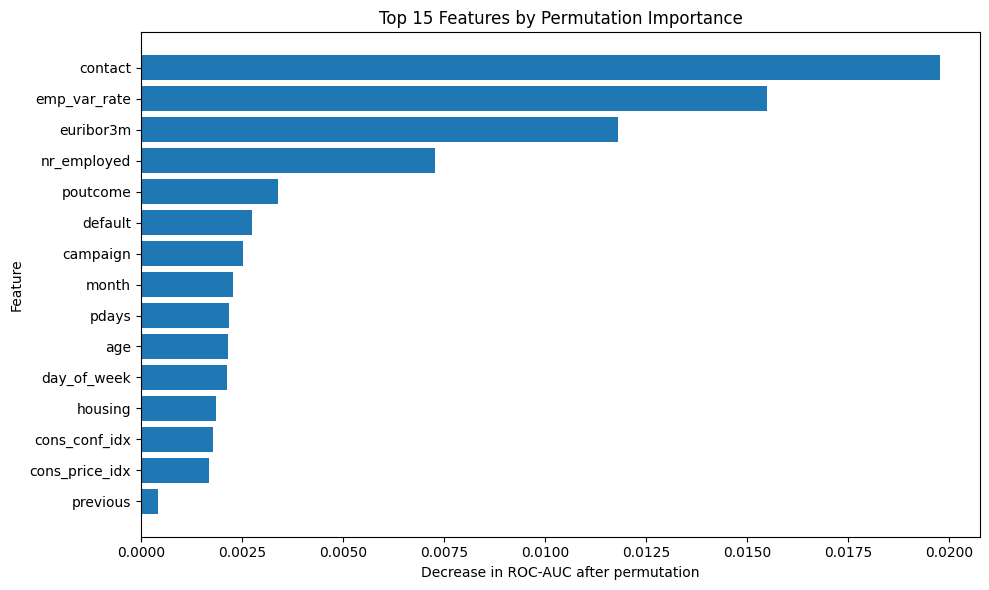

In [591]:
top_perm_features = perm_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_perm_features["feature"][::-1],
    top_perm_features["importance_mean"][::-1]
)
plt.xlabel("Decrease in ROC-AUC after permutation")
plt.ylabel("Feature")
plt.title("Top 15 Features by Permutation Importance")
plt.tight_layout()
plt.show()

### Permutation Importance Result

Permutation importance shows that the most important variables for the selected Random Forest model were:

1. `contact`
2. `emp_var_rate`
3. `euribor3m`
4. `nr_employed`
5. `poutcome`

The strongest variable was `contact`, suggesting that the communication channel was highly relevant for predicting subscription probability.

Several economic variables also appeared among the most important predictors, especially `emp_var_rate`, `euribor3m`, and `nr_employed`. This indicates that macroeconomic context plays an important role in the model's predictions.

The previous campaign outcome variable, `poutcome`, was also important, which is consistent with the exploratory analysis where clients with previous successful campaign outcomes had much higher subscription rates.

Overall, the model appears to rely most on:

- contact channel
- macroeconomic indicators
- previous campaign information
- campaign intensity variables

This supports the business interpretation that subscription propensity is influenced not only by client characteristics, but also by campaign context and broader economic conditions.

-----

## Error Analysis

After selecting Random Forest with a tuned threshold as the strongest realistic model by F1-score, error analysis is used to understand the model's mistakes.

For this marketing problem, the two most important error types are:

- **False positives**: clients predicted to subscribe who did not subscribe
- **False negatives**: clients predicted not to subscribe who actually subscribed

False positives represent wasted marketing contact effort, while false negatives represent missed subscription opportunities.

In [593]:
rf_selected_threshold = rf_threshold_result["best_threshold"]

y_pred_rf_selected = (y_prob_rf_test >= rf_selected_threshold).astype(int)

error_df = X_test.drop(columns=["duration"]).copy()
error_df["actual"] = y_test.values
error_df["predicted"] = y_pred_rf_selected
error_df["predicted_probability"] = y_prob_rf_test

error_df["error_type"] = np.select(
    [
        (error_df["actual"] == 1) & (error_df["predicted"] == 1),
        (error_df["actual"] == 0) & (error_df["predicted"] == 0),
        (error_df["actual"] == 0) & (error_df["predicted"] == 1),
        (error_df["actual"] == 1) & (error_df["predicted"] == 0)
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    default="Unknown" # Explicitly setting a string default value
)

error_df["error_type"].value_counts()

,count
error_type,
True Negative,6726
False Positive,584
True Positive,545
False Negative,383


In [594]:
error_df.groupby("error_type")["predicted_probability"].describe()

,count,mean,std,min,25%,50%,75%,max
error_type,,,,,,,,
False Negative,383.0,0.258944,0.131109,0.023505,0.161284,0.233802,0.329018,0.574004
False Positive,584.0,0.732423,0.097139,0.576305,0.656074,0.720756,0.801646,0.980451
True Negative,6726.0,0.204929,0.103298,0.024981,0.128319,0.186306,0.262337,0.575386
True Positive,545.0,0.799259,0.105180,0.579171,0.714392,0.804177,0.883060,0.988876


In [595]:
categorical_error_features = [
    "job",
    "education",
    "marital",
    "contact",
    "month",
    "poutcome",
    "default"
]

for feature in categorical_error_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            error_df[feature],
            error_df["error_type"],
            normalize="columns"
        ).round(3)
    )


job


error_type,False Negative,False Positive,True Negative,True Positive
job,,,,
admin.,0.240,0.301,0.245,0.349
blue-collar,0.232,0.063,0.246,0.062
entrepreneur,0.037,0.026,0.038,0.018
housemaid,0.005,0.024,0.025,0.033
management,0.073,0.065,0.072,0.057
retired,0.034,0.154,0.026,0.134
self-employed,0.037,0.034,0.040,0.029
services,0.115,0.055,0.100,0.046
student,0.021,0.075,0.009,0.092



education


error_type,False Negative,False Positive,True Negative,True Positive
education,,,,
basic.4y,0.070,0.089,0.107,0.105
basic.6y,0.047,0.024,0.057,0.026
basic.9y,0.175,0.062,0.160,0.068
high.school,0.235,0.211,0.235,0.231
illiterate,0.000,0.000,0.000,0.002
professional.course,0.141,0.118,0.128,0.125
university.degree,0.298,0.433,0.276,0.387
unknown,0.034,0.063,0.038,0.057



marital


...

error_type,False Negative,False Positive,True Negative,True Positive
month,,,,
apr,0.068,0.171,0.050,0.158
aug,0.128,0.173,0.149,0.138
dec,0.000,0.031,0.001,0.031
jul,0.211,0.065,0.187,0.066
jun,0.094,0.151,0.129,0.150
mar,0.003,0.084,0.000,0.106
may,0.397,0.068,0.376,0.064
nov,0.081,0.068,0.106,0.097
oct,0.010,0.106,0.001,0.105



poutcome


error_type,False Negative,False Positive,True Negative,True Positive
poutcome,,,,
failure,0.112,0.233,0.086,0.125
nonexistent,0.883,0.644,0.912,0.554
success,0.005,0.123,0.003,0.321



default


error_type,False Negative,False Positive,True Negative,True Positive
default,,,,
no,0.817,0.979,0.768,0.978
unknown,0.183,0.021,0.232,0.022


In [596]:
numeric_error_features = [
    "age",
    "campaign",
    "pdays",
    "previous",
    "emp_var_rate",
    "cons_price_idx",
    "cons_conf_idx",
    "euribor3m",
    "nr_employed"
]

error_df.groupby("error_type")[numeric_error_features].mean().round(2)

,age,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
error_type,,,,,,,,,
False Negative,39.53,2.53,993.82,0.14,0.03,93.52,-41.90,3.50,5167.90
False Positive,42.49,1.87,859.66,0.49,-2.41,92.99,-37.86,1.05,5050.85
True Negative,39.70,2.74,996.05,0.09,0.50,93.66,-40.80,4.08,5188.09
True Positive,42.30,1.70,661.80,0.71,-2.25,93.20,-38.31,1.03,5039.28


In [597]:
key_categorical_error_features = [
    "contact",
    "poutcome",
    "month",
    "job"
]

for feature in key_categorical_error_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            error_df[feature],
            error_df["error_type"],
            normalize="columns"
        ).round(3)
    )


contact


error_type,False Negative,False Positive,True Negative,True Positive
contact,,,,
cellular,0.7,0.914,0.583,0.938
telephone,0.3,0.086,0.417,0.062



poutcome


error_type,False Negative,False Positive,True Negative,True Positive
poutcome,,,,
failure,0.112,0.233,0.086,0.125
nonexistent,0.883,0.644,0.912,0.554
success,0.005,0.123,0.003,0.321



month


error_type,False Negative,False Positive,True Negative,True Positive
month,,,,
apr,0.068,0.171,0.050,0.158
aug,0.128,0.173,0.149,0.138
dec,0.000,0.031,0.001,0.031
jul,0.211,0.065,0.187,0.066
jun,0.094,0.151,0.129,0.150
mar,0.003,0.084,0.000,0.106
may,0.397,0.068,0.376,0.064
nov,0.081,0.068,0.106,0.097
oct,0.010,0.106,0.001,0.105



job


error_type,False Negative,False Positive,True Negative,True Positive
job,,,,
admin.,0.240,0.301,0.245,0.349
blue-collar,0.232,0.063,0.246,0.062
entrepreneur,0.037,0.026,0.038,0.018
housemaid,0.005,0.024,0.025,0.033
management,0.073,0.065,0.072,0.057
retired,0.034,0.154,0.026,0.134
self-employed,0.037,0.034,0.040,0.029
services,0.115,0.055,0.100,0.046
student,0.021,0.075,0.009,0.092


### Error Analysis Result

The error analysis shows that most model mistakes are understandable from a business perspective.

The tuned Random Forest model produced:

- 6,726 true negatives
- 584 false positives
- 545 true positives
- 383 false negatives

False positives had high predicted probabilities, with a median probability of 0.721. This means the model strongly classified these clients as likely subscribers, even though they did not subscribe.

False negatives had much lower predicted probabilities, with a median probability of 0.234. This suggests that many missed subscribers did not look strongly similar to the typical subscriber profile learned by the model.

Numerically, false positives looked similar to true positives. Both groups were associated with lower `emp_var_rate`, lower `euribor3m`, lower `nr_employed`, and higher previous campaign contact compared with true negatives. These are characteristics that the model associates with higher subscription probability.

The categorical error analysis shows a similar pattern.

False positives and true positives were mostly contacted by cellular phone. True positives also had a much higher proportion of previous campaign success through `poutcome = success`.

False negatives were more likely to have `poutcome = nonexistent`, meaning there was no previous campaign outcome available. They also had higher proportions of contact by telephone and were more concentrated in months such as `may` and `jul`, which had weaker subscription patterns in the EDA.

Job patterns also differed. True positives and false positives had higher proportions of groups such as `admin.`, `retired`, and `student`, while false negatives had higher proportions of `blue-collar`, `services`, and `technician`.

Overall, the model is better at identifying subscribers with clear favorable signals, such as cellular contact, favorable economic conditions, and previous campaign success. It struggles more with subscribers who resemble the majority non-subscriber profile or who lack strong previous-campaign indicators.

------------------

## Final Model Selection

After comparing several realistic no-duration models, the selected final model is **Random Forest with a tuned classification threshold**.

The model with `duration` achieved the strongest overall performance, but it is not suitable for realistic pre-campaign targeting because `duration` is only known after the call has already happened.

Among the realistic models, Random Forest with a tuned threshold achieved the best F1-score:

- Precision: 0.483
- Recall: 0.587
- F1-score: 0.530
- ROC-AUC: 0.808
- Threshold: 0.575

XGBoost achieved the highest ROC-AUC, suggesting stronger ranking ability, but Random Forest produced the best balance between precision and recall at the classification level.

For this project, F1-score is prioritized because the business goal is to balance two competing objectives:

- identifying likely subscribers
- avoiding excessive false positives

Therefore, Random Forest with a tuned threshold is selected as the final realistic model.

## Business Recommendations

Based on the modeling results, the bank should use the model as a decision-support tool for campaign targeting rather than as a fully automated decision system.

The model can help prioritize clients who are more likely to subscribe to a term deposit, especially when campaign resources are limited.

Key recommendations:

1. Use predicted probabilities to rank clients before campaign contact.
2. Prioritize clients with higher predicted subscription probability.
3. Adjust the classification threshold depending on campaign strategy.
4. Use a lower threshold when the goal is to maximize reach and capture more potential subscribers.
5. Use a higher threshold when the goal is to reduce unnecessary contacts and improve precision.
6. Monitor model performance over time because economic conditions and customer behavior may change.

The model showed that subscription propensity is influenced by campaign context, contact channel, previous campaign outcome, and macroeconomic indicators. Therefore, campaign planning should consider not only client characteristics, but also timing and broader economic conditions.